In [1]:
import tensorflow as tf
import numpy as np

In [4]:
x_vals = np.array([1., 3., 5., 7., 9.])
x_data = tf.placeholder(tf.float32)
m_const = tf.constant(3.)
my_product = tf.multiply(x_data, m_const)
with tf.Session() as sess:
    for x_val in x_vals:
        print(sess.run(my_product, feed_dict ={x_data:x_val}))


3.0
9.0
15.0
21.0
27.0


In [5]:
sess.close()

Working with Multiple Layer

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
from tensorflow.python.framework import ops
ops.reset_default_graph()

In [9]:
sess = tf.Session()

In [10]:
#create a 2D image with number, height, width and channel of image
x_shape = [1,4,4,1]
x_val = np.random.uniform(size = x_shape)
#create a placeholder to feed the sample image
x_data = tf.placeholder(tf.float32, shape = x_shape)

In [11]:
#create a moving window average
my_filter = tf.constant(0.25, shape = [2,2,1,1])
my_strides = [1,2,2,1]
mov_avg_layer = tf.nn.conv2d(x_data, my_filter, my_strides , padding = 'SAME', 
                            name = 'Moving_Average_Window')

In [13]:
#define a custom layer
def custom_layer(input_matrix):
    input_matrix_squeezed = tf.squeeze(input_matrix)
    A = tf.constant([[1., 2.],[-1., 3.]])
    b = tf.constant(1., shape = [2,2])
    temp1 = tf.matmul(A, input_matrix_squeezed)
    temp = tf.add(temp1, b) #A*x +b
    return (tf.sigmoid(temp))

#place new layer on the graph
with tf.name_scope('Custom_Layer') as scope:
    custom_layer1 = custom_layer(mov_avg_layer)

In [14]:
print(sess.run(mov_avg_layer, feed_dict={x_data: x_val}))

[[[[ 0.47999099]
   [ 0.23582853]]

  [[ 0.371461  ]
   [ 0.42601761]]]]


In [15]:
print(sess.run(custom_layer1, feed_dict={x_data: x_val}))

[[ 0.90228832  0.889718  ]
 [ 0.83677036  0.88515961]]


In [16]:
merged = tf.summary.merge_all(key='summaries')

if not os.path.exists('tensorboard_logs/'):
    os.makedirs('tensorboard_logs/')

my_writer = tf.summary.FileWriter('tensorboard_logs/', sess.graph)



Implementing Loss Function

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

In [4]:
sess = tf.Session()

We implement loass function for regression

In [5]:
#create variable
x_vals = tf.linspace(-1.,1.,500)
#create target
target = tf.constant(0.)

In [6]:
#Euclidean loss function
l2_y_vals = tf.square(target - x_vals)
l2_y_out = sess.run(l2_y_vals)

In [8]:
#Absolute loss function
l1_y_vals = tf.abs(target - x_vals)
l1_y_out = sess.run(l1_y_vals)

In [9]:
# Pseudo-Huber with delta = 0.25
delta1 = tf.constant(0.25)
phuber1_y_vals = tf.multiply(tf.square(delta1), tf.sqrt(1. + tf.square((target - x_vals)/delta1)) - 1.)
phuber1_y_out = sess.run(phuber1_y_vals)

# Pseudo-Huber with delta = 5
delta2 = tf.constant(5.)
phuber2_y_vals = tf.multiply(tf.square(delta2), tf.sqrt(1. + tf.square((target - x_vals)/delta2)) - 1.)
phuber2_y_out = sess.run(phuber2_y_vals)

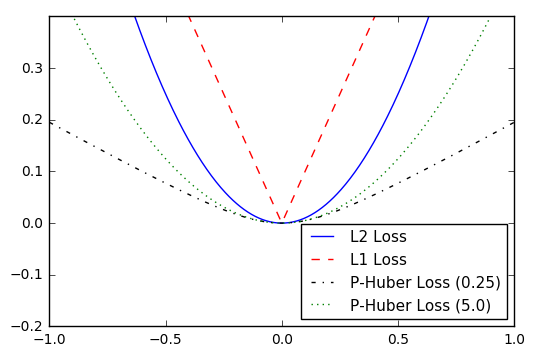

In [10]:
x_array = sess.run(x_vals)
plt.plot(x_array, l2_y_out, 'b-', label='L2 Loss')
plt.plot(x_array, l1_y_out, 'r--', label='L1 Loss')
plt.plot(x_array, phuber1_y_out, 'k-.', label='P-Huber Loss (0.25)')
plt.plot(x_array, phuber2_y_out, 'g:', label='P-Huber Loss (5.0)')
plt.ylim(-0.2, 0.4)
plt.legend(loc='lower right', prop={'size': 11})
plt.show()

Implementing Back Propagation

In [1]:
import numpy as np
import tensorflow as tf

In [2]:
sess = tf.Session()

In [3]:
#Create data, placeholders ans variables A
x_vals = np.random.normal(1, 0.1, 100) # means = 1, standard deviation = 0.1, number of samples = 100
y_vals = np.repeat(10., 100)
x_data = tf.placeholder(shape = [1], dtype = tf.float32)
y_target = tf.placeholder(shape = [1], dtype = tf.float32)
A = tf.Variable(tf.random_normal(shape = [1]))

In [5]:
#add the multiplication operation
my_output = tf.multiply(x_data, A)
#loss function 
loss = tf.square(my_output - y_target)

In [9]:
init = tf.global_variables_initializer()
sess.run(init)

In [10]:
my_opt = tf.train.GradientDescentOptimizer(learning_rate = 0.02)
train_step = my_opt.minimize(loss)

In [13]:
#train 101 time, print out result every 10th iteration
for i in range(100):
    rand_index = np.random.choice(100)
    rand_x = [x_vals[rand_index]]
    rand_y = [y_vals[rand_index]]
    sess.run(train_step, feed_dict = {x_data: rand_x, y_target: rand_y})
    if (i+1)%10 == 0:
        print('Step #' + str(i+1) + ' A = ' + str(sess.run(A)))
        print('Loss = ' + str(sess.run(loss, feed_dict = {x_data :rand_x, y_target :rand_y})))

Step #10 A = [ 9.72766972]
Loss = [ 0.00081255]
Step #20 A = [ 9.54935074]
Loss = [ 0.1752995]
Step #30 A = [ 9.58320141]
Loss = [ 0.28859609]
Step #40 A = [ 9.60534]
Loss = [ 0.36491057]
Step #50 A = [ 9.83488655]
Loss = [ 0.79226696]
Step #60 A = [ 9.87930298]
Loss = [ 0.15311511]
Step #70 A = [ 10.00410652]
Loss = [ 0.04609025]
Step #80 A = [ 10.07203865]
Loss = [ 1.15257561]
Step #90 A = [ 10.17068386]
Loss = [ 1.5508275]
Step #100 A = [ 10.03474903]
Loss = [ 1.84889615]


In [14]:
sess.close()

In [1]:
#code for simple classification
#reset the graph and reinitialize graph session
import tensorflow as tf
import numpy as np
from tensorflow.python.framework import ops
ops.reset_default_graph()

In [2]:
sess = tf.Session()

In [3]:
#create datr from 2 different normal distribution N(-1,1) and N(3,1)
x_vals = np.concatenate((np.random.normal(-1, 1, 50), np.random.normal(3, 1, 50)))
y_vals = np.concatenate((np.repeat(0., 50), np.repeat(0., 50)))
x_data = tf.placeholder(shape = [1], dtype = tf.float32)
y_target = tf.placeholder(shape = [1], dtype = tf.float32)
A = tf.Variable(tf.random_normal(mean = 10, shape = [1]))

In [4]:
my_output = tf.add(x_data, A)

In [5]:
#Add other dimension of batch ( is 0) 
my_output_expanded = tf.expand_dims(my_output, 0)
y_target_expanded = tf.expand_dims(y_target, 0)

In [7]:
#Initialize varialbe A
init = tf.global_variables_initializer()
sess.run(init)

In [11]:
#declare the loss function
#using cross entropy with unscaled logits and a sigmoid function
x_entropy = tf.nn.sigmoid_cross_entropy_with_logits(labels = y_target_expanded, logits = None, name = None)


ValueError: Both labels and logits must be provided.

Working with Batch and Stochastic Training

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
sess = tf.Session()

In [33]:
batch_size = 20

In [34]:
#variables, copy from above
#create data from 2 different normal distribution N(-1,1) and N(3,1)
x_vals = np.random.normal(1, 0.1, 100)
y_vals = np.repeat(10., 1000)
x_data = tf.placeholder(shape = [None, 1], dtype = tf.float32)
y_target = tf.placeholder(shape = [None, 1], dtype = tf.float32)
A = tf.Variable(tf.random_normal(shape = [1,1]))

In [35]:
my_output = tf.multiply(x_data, A)

In [36]:
loss = tf.reduce_mean(tf.square(my_output - y_target))

In [37]:
# Initialize variables
init = tf.global_variables_initializer()
sess.run(init)

#declare optimizer
my_opt = tf.train.GradientDescentOptimizer(0.02)
train_step = my_opt.minimize(loss)

In [38]:
#@training for batch training
loss_batch = []
for i in range(100):
    rand_index = np.random.choice(100, size = batch_size)
    rand_x = np.transpose([x_vals[rand_index]])
    rand_y = np.transpose([y_vals[rand_index]])
    sess.run(train_step, feed_dict={x_data: rand_x, y_target: rand_y})
    if (i+1)%5==0:
        print('Step #' + str(i+1) + ' A = ' + str(sess.run(A)))
        temp_loss = sess.run(loss, feed_dict={x_data: rand_x, y_target: rand_y})
        print('Loss = ' + str(temp_loss))
        loss_batch.append(temp_loss)

Step #5 A = [[ 1.37001669]]
Loss = 74.3322
Step #10 A = [[ 2.9545598]]
Loss = 49.444
Step #15 A = [[ 4.24743176]]
Loss = 32.1517
Step #20 A = [[ 5.30016088]]
Loss = 22.0019
Step #25 A = [[ 6.15647888]]
Loss = 15.7923
Step #30 A = [[ 6.85407925]]
Loss = 10.629
Step #35 A = [[ 7.4118824]]
Loss = 5.69027
Step #40 A = [[ 7.86198807]]
Loss = 6.05298
Step #45 A = [[ 8.23958588]]
Loss = 3.56889
Step #50 A = [[ 8.54669476]]
Loss = 3.64424
Step #55 A = [[ 8.80306911]]
Loss = 2.39763
Step #60 A = [[ 9.00650406]]
Loss = 1.86661
Step #65 A = [[ 9.18788528]]
Loss = 1.83177
Step #70 A = [[ 9.29549503]]
Loss = 1.32416
Step #75 A = [[ 9.42838955]]
Loss = 1.35281
Step #80 A = [[ 9.50383472]]
Loss = 0.726931
Step #85 A = [[ 9.5673933]]
Loss = 0.750928
Step #90 A = [[ 9.62471485]]
Loss = 0.655914
Step #95 A = [[ 9.65542412]]
Loss = 1.00733
Step #100 A = [[ 9.70735264]]
Loss = 0.856555


In [39]:
#@training for stochastic training
loss_stochastic = []
for i in range(100):
    rand_index = np.random.choice(100, size = batch_size)
    rand_x = np.transpose([x_vals[rand_index]])
    rand_y = np.transpose([y_vals[rand_index]])
    sess.run(train_step, feed_dict={x_data: rand_x, y_target: rand_y})
    if (i+1)%5==0:
        print('Step #' + str(i+1) + ' A = ' + str(sess.run(A)))
        temp_loss = sess.run(loss, feed_dict={x_data: rand_x, y_target: rand_y})
        print('Loss = ' + str(temp_loss))
        loss_stochastic.append(temp_loss)

Step #5 A = [[ 9.72489262]]
Loss = 1.09905
Step #10 A = [[ 9.73714161]]
Loss = 1.1734
Step #15 A = [[ 9.76801586]]
Loss = 1.19868
Step #20 A = [[ 9.78661633]]
Loss = 1.61574
Step #25 A = [[ 9.81865597]]
Loss = 1.33382
Step #30 A = [[ 9.84693146]]
Loss = 1.26832
Step #35 A = [[ 9.85782242]]
Loss = 1.32584
Step #40 A = [[ 9.83262539]]
Loss = 1.36227
Step #45 A = [[ 9.85146523]]
Loss = 1.08137
Step #50 A = [[ 9.84953976]]
Loss = 1.29552
Step #55 A = [[ 9.89168072]]
Loss = 1.53683
Step #60 A = [[ 9.8812952]]
Loss = 0.941687
Step #65 A = [[ 9.92783833]]
Loss = 0.7877
Step #70 A = [[ 9.94504166]]
Loss = 1.80562
Step #75 A = [[ 9.93651009]]
Loss = 0.961799
Step #80 A = [[ 9.91961098]]
Loss = 0.717649
Step #85 A = [[ 9.91333389]]
Loss = 1.01247
Step #90 A = [[ 9.88354874]]
Loss = 0.889006
Step #95 A = [[ 9.88426399]]
Loss = 1.23702
Step #100 A = [[ 9.88321209]]
Loss = 0.991907


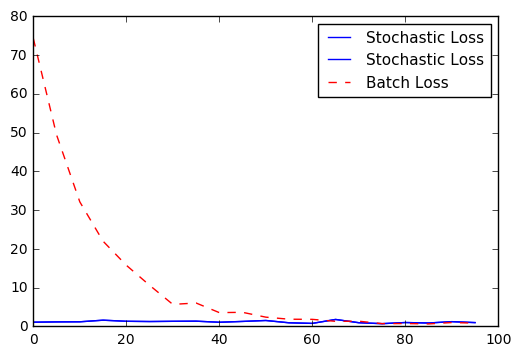

In [42]:
#plot the result
plt.plot(range(0,100,5), loss_stochastic, 'b-', label = 'Stochastic Loss')
plt.plot(range(0,100,5), loss_batch, 'r--', label = 'Batch Loss')
plt.legend(loc = 'upper right', prop ={'size' : 11})
plt.show()

In [44]:
sess.close()

Combining Everything Together